In [2]:
# ==========================================
# Experiment Paths
# ==========================================

from pathlib import Path

EXPERIMENT_DIR = Path("../experiments/E04_ModelExplainability")

FIGURES_DIR = EXPERIMENT_DIR / "figures"
SHAP_DIR = EXPERIMENT_DIR / "shap_values"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SHAP_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt

from pathlib import Path

c:\Users\Rawan\CyberAttackDetectionSystem\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ==========================================
# Load Optimized Model
# ==========================================

MODEL_PATH = Path(
    "../experiments/E03_HyperparameterOptimization/trained_models/optimized_xgboost.pkl"
)

model = joblib.load(MODEL_PATH)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


In [5]:
# ==========================================
# Load Selected Features
# ==========================================

FEATURES_PATH = Path(
    "../experiments/E03_HyperparameterOptimization/feature_names.pkl"
)

selected_features = joblib.load(FEATURES_PATH)

print(selected_features)

print(len(selected_features))

['Destination Port', 'Bwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Header Length', 'Init_Win_bytes_forward', 'Flow Duration', 'Bwd Packet Length Mean', 'Total Length of Fwd Packets', 'Packet Length Variance', 'Subflow Fwd Bytes', 'Bwd Packets/s', 'Average Packet Size', 'Packet Length Std', 'Init_Win_bytes_backward', 'Packet Length Mean', 'Fwd Header Length', 'PSH Flag Count', 'Max Packet Length', 'Fwd IAT Mean', 'act_data_pkt_fwd', 'Fwd Packet Length Max', 'Min Packet Length', 'Fwd IAT Max', 'Flow IAT Max', 'Flow IAT Std', 'Flow IAT Mean', 'Bwd Packet Length Min', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd IAT Min']
30


In [6]:
# ==========================================
# Load Label Encoder
# ==========================================

ENCODER_PATH = Path(
    "../experiments/E03_HyperparameterOptimization/label_encoder.pkl"
)

label_encoder = joblib.load(ENCODER_PATH)

print(label_encoder.classes_)

['Bots' 'Brute Force' 'DDoS' 'DoS' 'Normal Traffic' 'Port Scanning'
 'Web Attacks']


In [7]:
# ==========================================
# Load Dataset
# ==========================================

DATA_PATH = "../data/cicids2017_cleaned.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(2520751, 53)


In [8]:
# ==========================================
# Select Model Features
# ==========================================

X = df[selected_features]

print(X.shape)

(2520751, 30)


In [9]:
# ==========================================
# Sample Data for SHAP
# ==========================================

X_sample = X.sample(

    n=1000,

    random_state=42

)

print(X_sample.shape)

(1000, 30)


In [10]:
# ==========================================
# Compute SHAP Values
# ==========================================

explainer = shap.TreeExplainer(model)

shap_values = explainer(X_sample)

In [11]:
# ==========================================
# Calculate SHAP Values
# ==========================================
# Compute SHAP values for the sampled data
# using the optimized XGBoost model.

shap_values = explainer.shap_values(X_sample)

print("SHAP values successfully calculated.")

SHAP values successfully calculated.


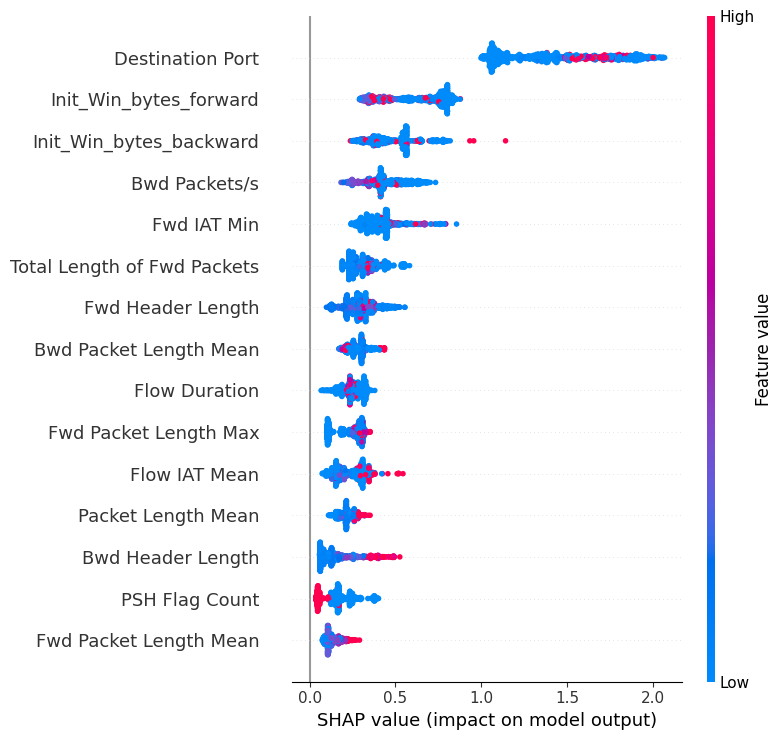

In [12]:
# ==========================================
# SHAP Summary Plot
# ==========================================
# Global explanation of the optimized XGBoost model
# using mean absolute SHAP values across all classes.

mean_shap_values = np.mean(

    np.abs(shap_values),

    axis=2

)


shap.summary_plot(

    mean_shap_values,

    X_sample,

    max_display=15,

    show=False

)


plt.tight_layout()


plt.savefig(

    FIGURES_DIR / "shap_summary.png",

    dpi=300,

    bbox_inches="tight"

)


plt.show()

In [13]:
print(type(shap_values))

<class 'numpy.ndarray'>


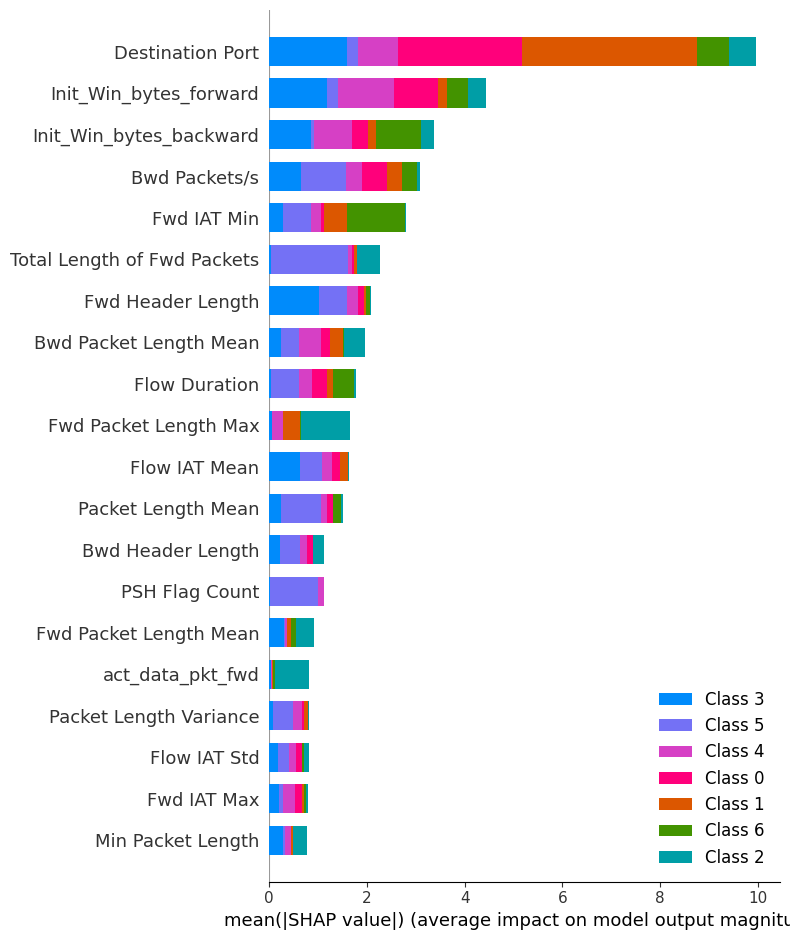

In [14]:
# ==========================================
# SHAP Feature Importance
# ==========================================

plt.figure(figsize=(10,8))

shap.summary_plot(

    shap_values,

    X_sample,

    plot_type="bar",

    show=False

)

plt.tight_layout()

plt.savefig(

    FIGURES_DIR /

    "shap_feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [15]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1000, 30, 7)


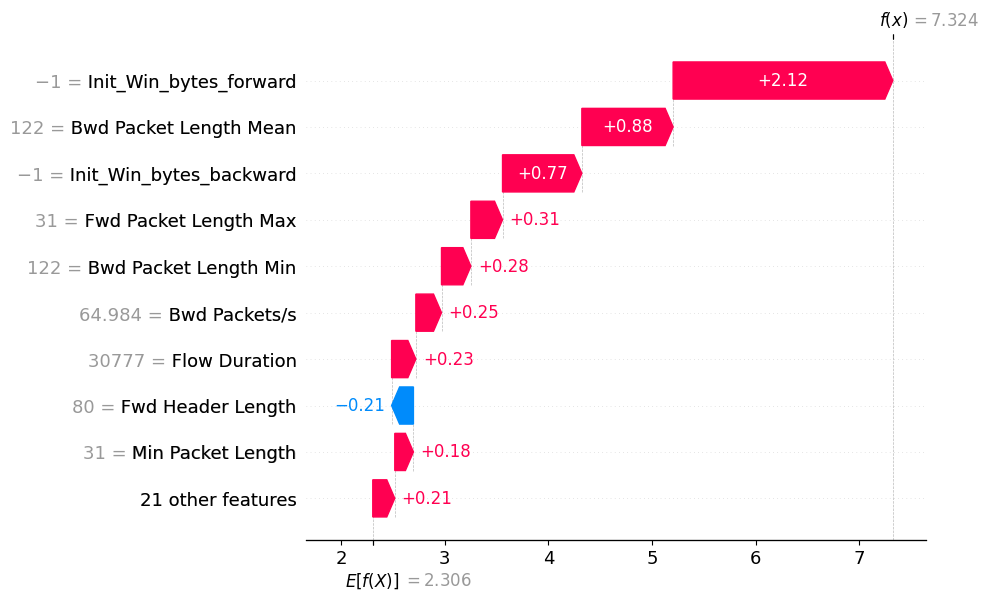

In [16]:
# ==========================================
# SHAP Waterfall Plot
# ==========================================

# Select one sample to explain
sample_index = 0

# Predict the class of the selected sample
predicted_class = model.predict(X_sample.iloc[[sample_index]])[0]

# Create SHAP explanation for the predicted class
explanation = shap.Explanation(

    values=shap_values[sample_index, :, predicted_class],

    base_values=explainer.expected_value[predicted_class],

    data=X_sample.iloc[sample_index],

    feature_names=X_sample.columns

)

# Generate Waterfall Plot
shap.plots.waterfall(

    explanation,

    show=False

)

# Save Figure
plt.savefig(

    FIGURES_DIR / "shap_waterfall.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [17]:
import shap

print(shap.__version__)

0.51.0


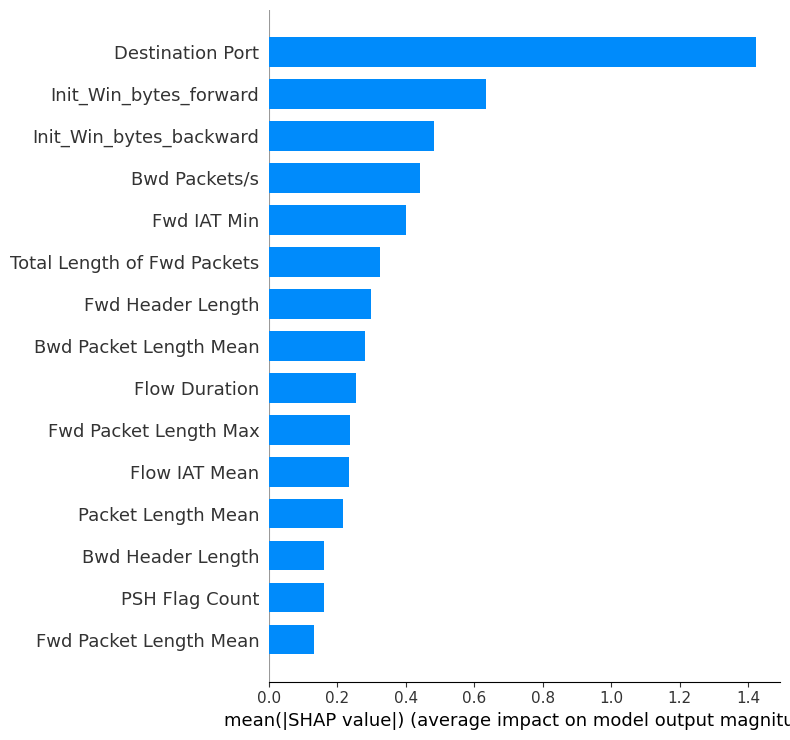

In [18]:
mean_shap = np.mean(np.abs(shap_values), axis=2)

plt.figure(figsize=(10,8))

shap.summary_plot(

    mean_shap,

    X_sample,

    plot_type="bar",

    max_display=15,

    show=False

)

plt.tight_layout()

plt.savefig(

    FIGURES_DIR / "shap_feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

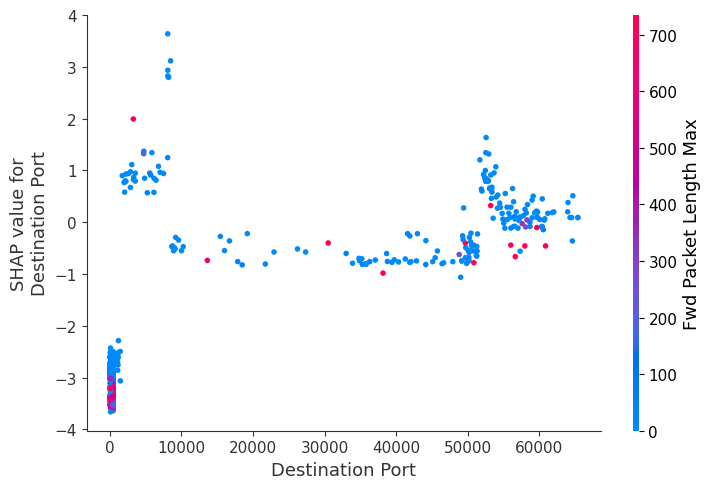

In [19]:
# ==========================================
# SHAP Dependence Plot
# ==========================================
# Visualize the relationship between one feature
# and its SHAP values for Class 0.

feature = X_sample.columns[0]

shap.dependence_plot(

    feature,

    shap_values[:, :, 0],   # Class 0

    X_sample,

    show=False

)

plt.tight_layout()

plt.savefig(

    FIGURES_DIR / "shap_dependence.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()